In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.metrics import r2_score, mean_squared_error

In [5]:
df=pd.read_csv(r"C:\Users\Dell\Downloads\housing.csv")

# eda part


In [6]:
df.shape

(20640, 10)

In [7]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [8]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [10]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [11]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

# handling missing value

In [12]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

In [13]:
df.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

# checking duplicates

In [14]:
df.duplicated().sum()

np.int64(0)

# correlation analysis

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

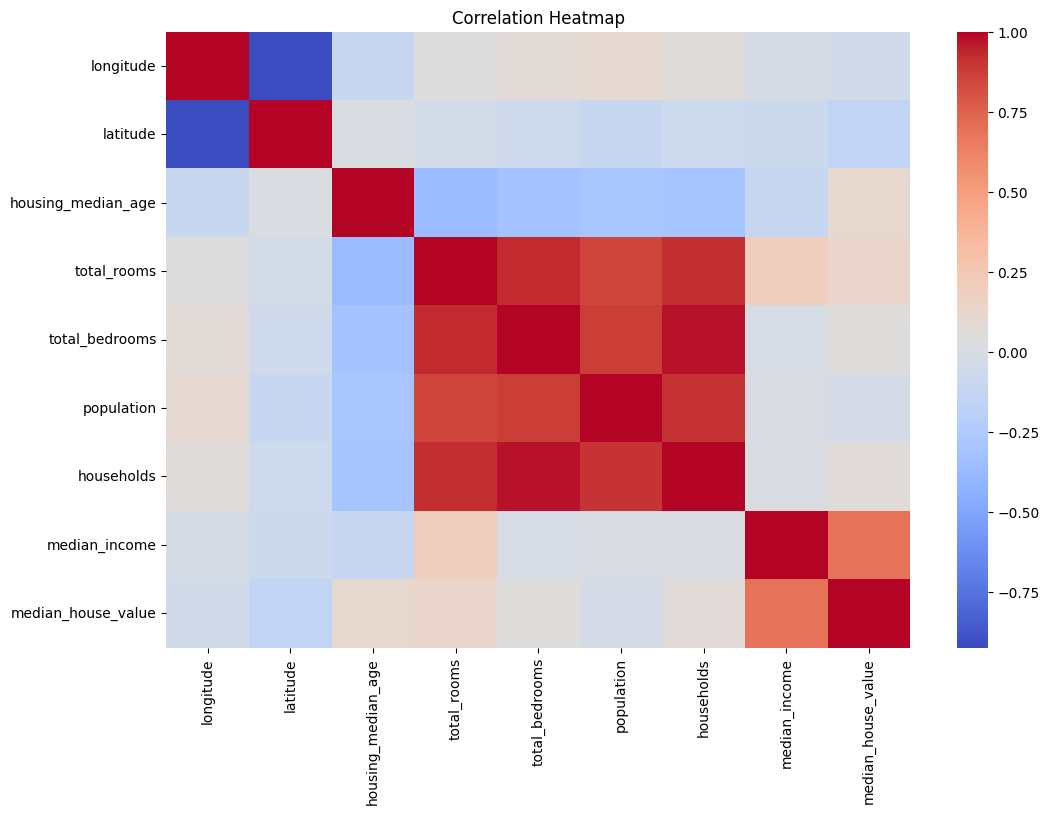

In [16]:
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# target variable distributn hisplot

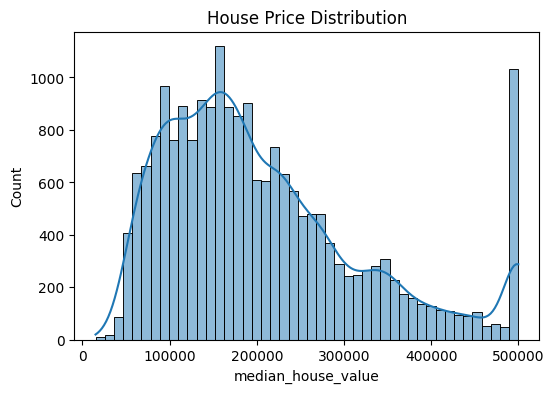

In [17]:
plt.figure(figsize=(6,4))
sns.histplot(df["median_house_value"], kde=True)
plt.title("House Price Distribution")
plt.show()

# outlier detection

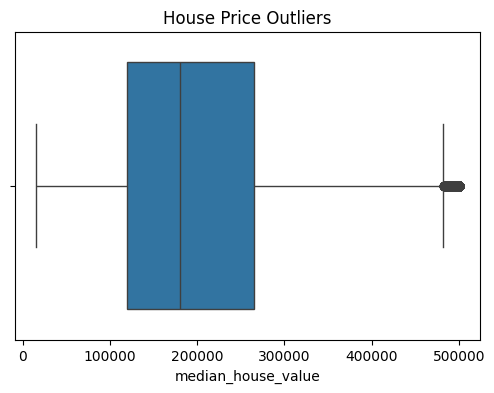

In [18]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["median_house_value"])
plt.title("House Price Outliers")
plt.show()

In [19]:
corr_target = corr["median_house_value"].sort_values(ascending=False)

print(corr_target.head(10))

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049457
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


# seperating numerical and categorical features

In [20]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include="object").columns

print("Numerical:", len(num_cols))
print("Categorical:", len(cat_cols))

Numerical: 9
Categorical: 1


# encoding

In [21]:
df = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True)

#seperating features and target variable

In [22]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2
)

# feature scaling

In [24]:
from sklearn.preprocessing import MinMaxScaler

In [25]:
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# linear regression

In [26]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Linear Regression R2:", r2_score(y_test, lr_pred))
print("Linear Regression MSE:", mean_squared_error(y_test, lr_pred))

Linear Regression R2: 0.6394912994332125
Linear Regression MSE: 4856140127.805727


# decision tree algorithm

In [27]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree R2:", r2_score(y_test, dt_pred))
print("Decision Tree MSE:", mean_squared_error(y_test, dt_pred))

Decision Tree R2: 0.6553172022797911
Decision Tree MSE: 4642961356.388566


# random forest regression

In [28]:

from sklearn.ensemble import RandomForestRegressor

In [29]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest R2:", r2_score(y_test, rf_pred))
print("Random Forest MSE:", mean_squared_error(y_test, rf_pred))

Random Forest R2: 0.819996123169398
Random Forest MSE: 2424696125.4011316


# knn

In [30]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

print("KNN R2:", r2_score(y_test, knn_pred))
print("KNN MSE:", mean_squared_error(y_test, knn_pred))

KNN R2: 0.7065136627872124
KNN MSE: 3953332546.0967827


# support vector reg

In [31]:
svr = SVR(kernel='rbf')
svr.fit(X_train, y_train)

svr_pred = svr.predict(X_test)

print("SVR R2:", r2_score(y_test, svr_pred))
print("SVR MSE:", mean_squared_error(y_test, svr_pred))

SVR R2: -0.05192435559927855
SVR MSE: 14169677643.31524


EVALUATION

In [32]:

print("LinearReg  :", r2_score(y_test, lr_pred))
print("DecisionTree  :", r2_score(y_test, dt_pred))
print("RandomForest  :", r2_score(y_test, rf_pred))
print("KNN :", r2_score(y_test, knn_pred))
print("SVR :", r2_score(y_test, svr_pred))

LinearReg  : 0.6394912994332125
DecisionTree  : 0.6553172022797911
RandomForest  : 0.819996123169398
KNN : 0.7065136627872124
SVR : -0.05192435559927855


DEPLOYMENT

In [33]:
model=rf

In [34]:
import pickle

with open("model.pkl", "wb") as f:   # wb = write binary
    pickle.dump(model, f)


In [35]:
import pickle

# Save trained model
pickle.dump(rf, open("model.pkl", "wb"))

# Save scaler
pickle.dump(scaler, open("scaler.pkl", "wb"))